##### This notebook will generate the figure for frequency of PG9-like precursors in the OAS database

## 1. Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
import math
import pandas as pd
import random

## 2. Import the frequency counts

In [2]:
path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/data/' # path to frequency count files

frequency_lists = []
list_names = []
for i in range(1,8): # there are 7 searches for PG9. Each search has a csv file. 
    df = pd.read_csv(f'{path}PG9_search{i}.csv')
    frequency_lists.append(df['conservative_frequency_estimate'])
    list_names.append(f'{i}')

## 3. Frequency per donor figure

    Add in averages across the donors that have precursors
        Essentially just an average of the points plotted on the graph

In [6]:
x_values = [] # Make a list of random x values for plotting the averages 
for i in range(len(list_names)):
    x_values.append(random.uniform(0,0.2)) # random numbers between 0 and 0.2 
print(x_values) 

# calculate the average frequency per donor. 
frequency_avgs = []
for i in range(len(list_names)):
    frequency_avgs.append(np.average(frequency_lists[i]))

list_c = ['0.9','0.4','0.9','0.4','0.9','0.4','0.9','0.4']

[0.1229398585900891, 0.19756217209256555, 0.04409528199798485, 0.0024809333473854393, 0.13852851349161496, 0.12684893934367933, 0.04942319640445867]


10 donors
0.5016187546417172
15 donors
15.135927458123518
23 donors
3.116059227656286
37 donors
9.56353020543049
99 donors
22.255805889206357
123 donors
39.85958919118897
152 donors
77.33753989300467


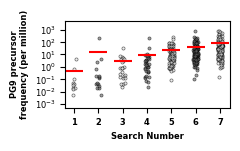

In [8]:
list_plot = [0,1,2,3,4,5,6]

line_size = 150 #50
dot_size = 5 # 600
xtick_size = 6 #12
ytick_size = 6
label_size = 6

# plot with different x tick names
plt.figure(figsize=[2.5,1.5]) # 7.5, 3.5
for i in range(len(list_plot)):    
    x_values = []
    for p in range(len(frequency_lists[list_plot[i]])):
        x_values.append(random.uniform(0,0.2))
    print(len(x_values), "donors")
    print(frequency_avgs[list_plot[i]])
    x_vals = np.array(x_values)
    plt.scatter(x_vals+i, frequency_lists[list_plot[i]], color=list_c[i], alpha=0.6, edgecolors='k', s=dot_size, linewidths=0.5)
    plt.scatter(0+i+0.1, frequency_avgs[list_plot[i]], marker='_', s=line_size, color='r',linewidths=1)
list_names = ['1', '2', '3', '4', '5', '6','7']
plt.xlabel("Search Number",  fontsize=label_size, weight='bold', fontname="Calibri")
plt.yscale("log")     
plt.xticks(np.array(np.arange(len(list_names)))+0.1, list_names, rotation = 0, fontsize=xtick_size, weight='bold',fontname="Calibri")
plt.ylabel("PG9 precursor\nfrequency (per million)", fontsize=label_size, weight='bold', fontname="Calibri")
plt.yticks([0.0001, 0.001,0.01,0.1,1,10,100,1000,10000],fontsize=ytick_size, fontname="Calibri")
plt.ylim(0.0005,5000)
plt.tight_layout()
figure_path = '/Users/ssolieva/Desktop/github_repo/q23-manuscript/repertoire-frequency-analysis/OAS-searches/figures/'
plt.savefig(f"{figure_path}SI_Fig1_PanelB__PG9_conservative_frequency_per_donor.pdf", dpi=300, transparent=True)
plt.show()